In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## 1. Load Dataset

In [8]:
# Change the filename if your CSV has a different name
df = pd.read_csv("HR_Employee_Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Understand the Dataset

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns)

Rows: 1470
Columns: 35

Column Names:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 3. Check Missing Values and Duplicates

In [12]:
print("Total Missing Values:", df.isnull().sum().sum())
print("\nMissing values by column:")
print(df.isnull().sum())

Total Missing Values: 0

Missing values by column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany     

In [13]:
print("Total Duplicate Rows:", df.duplicated().sum())

Total Duplicate Rows: 0


## 4. Target Variable

In [14]:
print(df["Attrition"].value_counts())
print("\nPercentage:")
print(df["Attrition"].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis

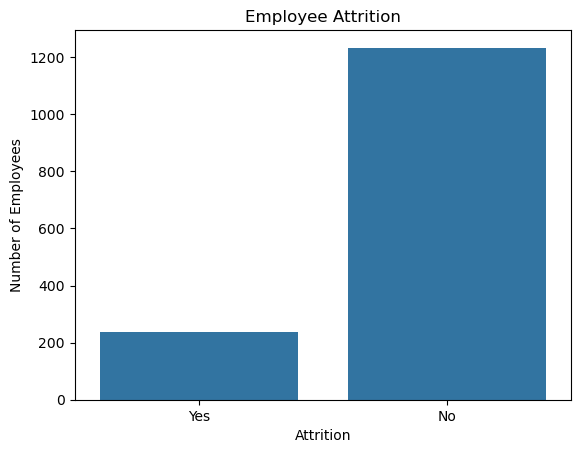

In [15]:
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

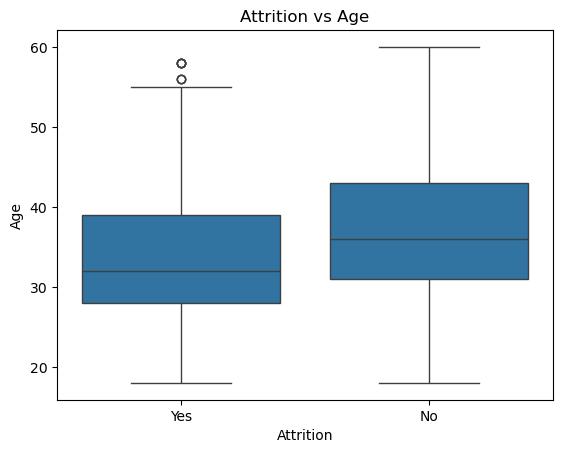

In [16]:
sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Attrition vs Age")
plt.show()

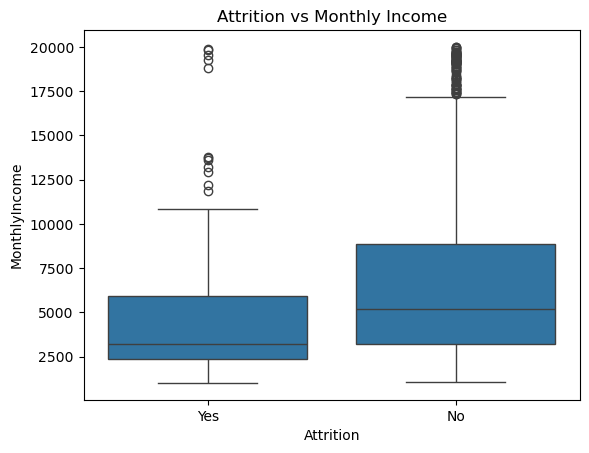

In [17]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

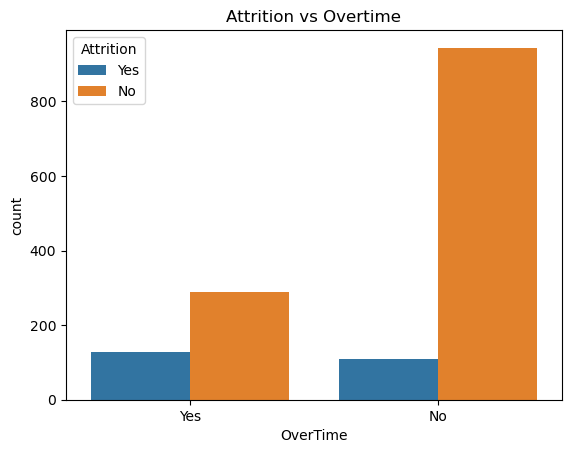

In [18]:
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Attrition vs Overtime")
plt.show()

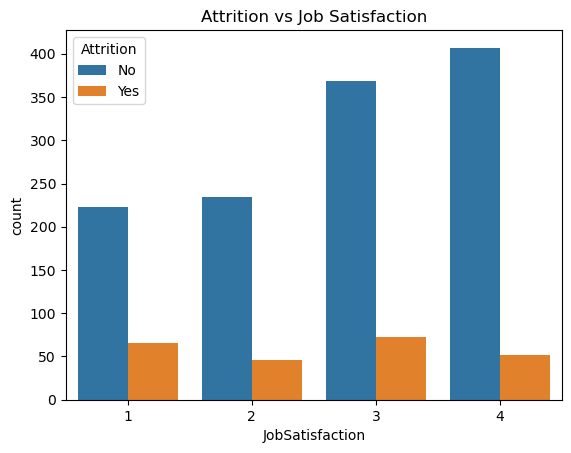

In [19]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.title("Attrition vs Job Satisfaction")
plt.show()

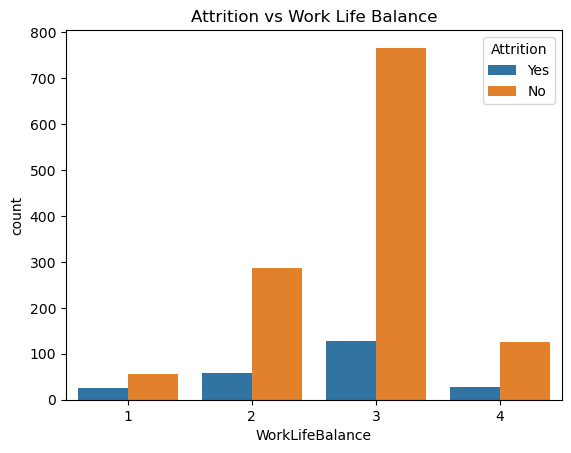

In [20]:
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df)
plt.title("Attrition vs Work Life Balance")
plt.show()

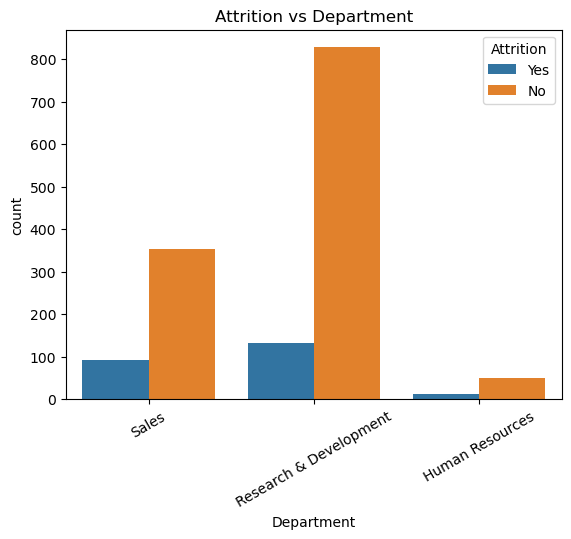

In [21]:
sns.countplot(x="Department", hue="Attrition", data=df)
plt.title("Attrition vs Department")
plt.xticks(rotation=30)
plt.show()

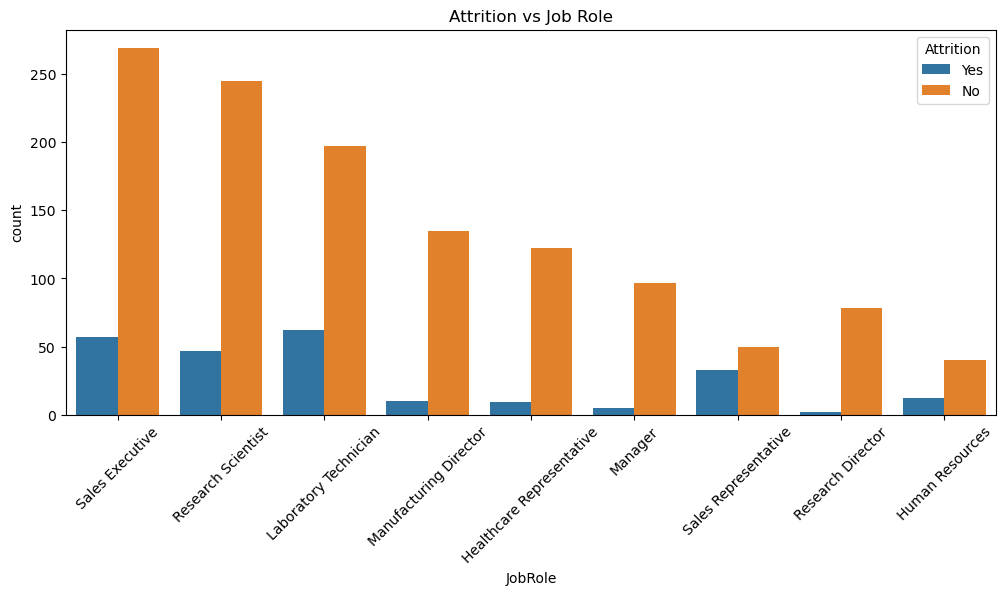

In [22]:
plt.figure(figsize=(12, 5))
sns.countplot(x="JobRole", hue="Attrition", data=df)
plt.title("Attrition vs Job Role")
plt.xticks(rotation=45)
plt.show()

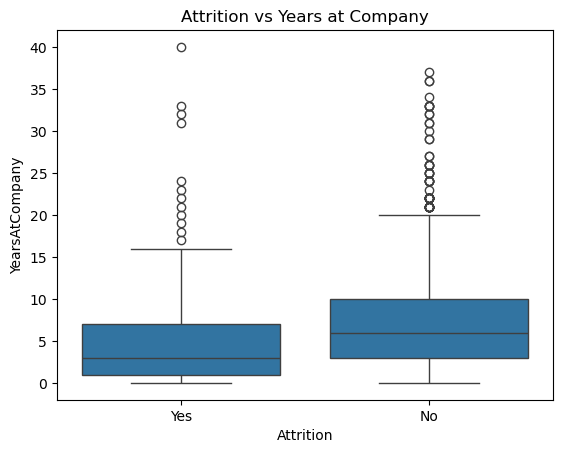

In [23]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)
plt.title("Attrition vs Years at Company")
plt.show()

## 6. Check Categorical and Numerical Columns

In [24]:
categorical_columns = df.select_dtypes(include="object").columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


## 7. Encode Target Variable

In [25]:
# No = Stay (0), Yes = Leave (1)
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

## 8. Separate Features and Target

In [26]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Convert categorical columns into numeric dummy columns
X = pd.get_dummies(X, drop_first=True)

print("Number of Features:", X.shape[1])
X.head()

Number of Features: 47


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,1,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,1,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


## 9. Train-Test Split (80/20)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 47)
Testing Data: (294, 47)


## 10. Feature Scaling

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 11. Logistic Regression

In [29]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))

Logistic Regression
Accuracy: 0.8605442176870748
Precision: 0.6153846153846154
Recall: 0.3404255319148936
F1 Score: 0.4383561643835616


## 12. KNN

In [30]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

KNN
Accuracy: 0.8435374149659864
Precision: 0.5555555555555556
Recall: 0.10638297872340426
F1 Score: 0.17857142857142858


## 13. Decision Tree

In [31]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train, y_train)
y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))

Decision Tree
Accuracy: 0.8333333333333334
Precision: 0.45
Recall: 0.19148936170212766
F1 Score: 0.26865671641791045


## 14. Random Forest

In [32]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8299319727891157
Precision: 0.36363636363636365
Recall: 0.0851063829787234
F1 Score: 0.13793103448275862


## 15. Gradient Boosting

In [33]:
gradient_model = GradientBoostingClassifier(random_state=42)
gradient_model.fit(X_train, y_train)

y_pred_gradient = gradient_model.predict(X_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gradient))
print("Precision:", precision_score(y_test, y_pred_gradient))
print("Recall:", recall_score(y_test, y_pred_gradient))
print("F1 Score:", f1_score(y_test, y_pred_gradient))

Gradient Boosting
Accuracy: 0.8435374149659864
Precision: 0.5294117647058824
Recall: 0.19148936170212766
F1 Score: 0.28125


## 16. Compare All Models

In [34]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gradient)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gradient)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gradient)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gradient)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356
1,KNN,0.843537,0.555556,0.106383,0.178571
2,Decision Tree,0.833333,0.450000,0.191489,0.268657
3,Random Forest,0.829932,0.363636,0.085106,0.137931
4,Gradient Boosting,0.843537,0.529412,0.191489,0.281250


## 17. Select Best Model

In [35]:
best_model_name = results.loc[results["F1 Score"].idxmax(), "Model"]
print("Best Model:", best_model_name)

predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gradient
}

best_predictions = predictions[best_model_name]

Best Model: Logistic Regression


## 18. Confusion Matrix

In [36]:
cm = confusion_matrix(y_test, best_predictions)
print(cm)

[[237  10]
 [ 31  16]]


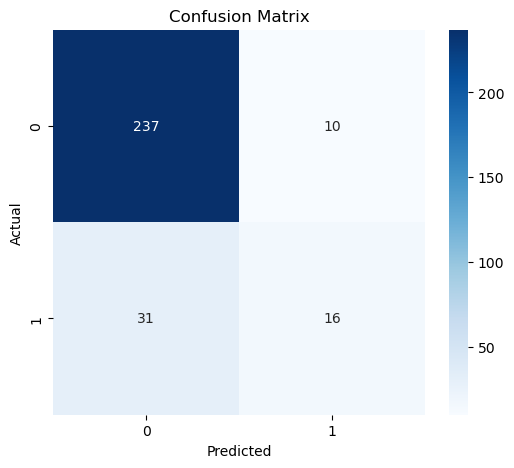

In [37]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
print(classification_report(
    y_test,
    best_predictions,
    target_names=["Stay", "Leave"]
))

              precision    recall  f1-score   support

        Stay       0.88      0.96      0.92       247
       Leave       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



## 19. Top 5 Important Features

In [39]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_5_features = feature_importance.head(5)
top_5_features

,Feature,Importance
11,MonthlyIncome,0.066978
19,TotalWorkingYears,0.065706
0,Age,0.059688
1,DailyRate,0.049455
12,MonthlyRate,0.046730


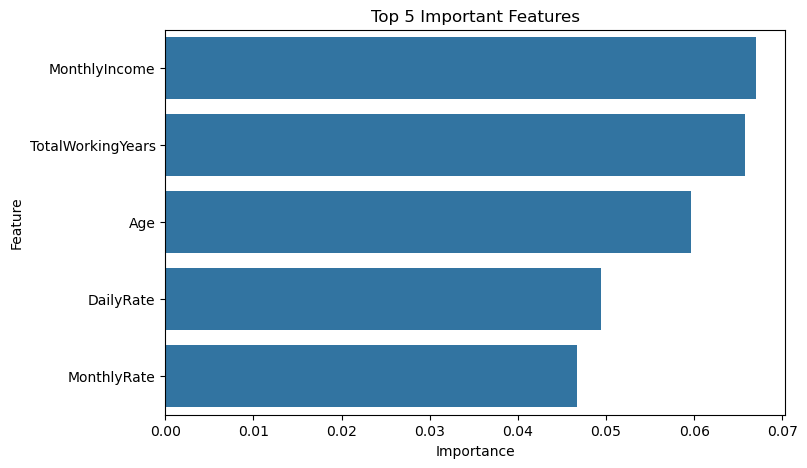

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top_5_features
)
plt.title("Top 5 Important Features")
plt.show()

## 20. New Employee Prediction

In [41]:
new_employee = {
    "Age": 30,
    "BusinessTravel": "Travel_Rarely",
    "DailyRate": 800,
    "Department": "Sales",
    "DistanceFromHome": 10,
    "Education": 3,
    "EducationField": "Life Sciences",
    "EmployeeCount": 1,
    "EmployeeNumber": 9999,
    "EnvironmentSatisfaction": 3,
    "Gender": "Male",
    "HourlyRate": 60,
    "JobInvolvement": 3,
    "JobLevel": 2,
    "JobRole": "Sales Executive",
    "JobSatisfaction": 3,
    "MaritalStatus": "Single",
    "MonthlyIncome": 5000,
    "MonthlyRate": 15000,
    "NumCompaniesWorked": 2,
    "Over18": "Y",
    "OverTime": "No",
    "PercentSalaryHike": 12,
    "PerformanceRating": 3,
    "RelationshipSatisfaction": 3,
    "StandardHours": 80,
    "StockOptionLevel": 0,
    "TotalWorkingYears": 8,
    "TrainingTimesLastYear": 3,
    "WorkLifeBalance": 3,
    "YearsAtCompany": 5,
    "YearsInCurrentRole": 3,
    "YearsSinceLastPromotion": 1,
    "YearsWithCurrManager": 3
}

new_employee_df = pd.DataFrame([new_employee])
new_employee_encoded = pd.get_dummies(new_employee_df)

new_employee_encoded = new_employee_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

new_employee_encoded.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,30,800,10,3,1,9999,3,60,3,2,...,0,0,0,0,0,True,0,0,True,0


## 21. Prepare New Employee for the Best Model

In [42]:
if best_model_name == "Logistic Regression":
    final_model = logistic_model
    new_data = scaler.transform(new_employee_encoded)

elif best_model_name == "KNN":
    final_model = knn_model
    new_data = scaler.transform(new_employee_encoded)

elif best_model_name == "Decision Tree":
    final_model = decision_tree_model
    new_data = new_employee_encoded

elif best_model_name == "Random Forest":
    final_model = random_forest_model
    new_data = new_employee_encoded

else:
    final_model = gradient_model
    new_data = new_employee_encoded

## 22. Predict Leave / Stay

In [43]:
prediction = final_model.predict(new_data)[0]

if prediction == 1:
    result = "Leave"
else:
    result = "Stay"

print("Prediction:", result)

Prediction: Stay


## 23. Attrition Probability

In [44]:
probability = final_model.predict_proba(new_data)[0][1]
print("Attrition Probability:", round(probability * 100, 2), "%")

Attrition Probability: 12.12 %


## 24. Risk Level

In [45]:
if probability < 0.30:
    risk = "Low"
elif probability < 0.60:
    risk = "Medium"
else:
    risk = "High"

print("Risk Level:", risk)

Risk Level: Low


## 25. Final Prediction Output

In [46]:
print("-----------------------------------")
print("EMPLOYEE ATTRITION PREDICTION")
print("-----------------------------------")
print("Prediction:", result)
print("Attrition Probability:", round(probability * 100, 2), "%")
print("Risk Level:", risk)
print("-----------------------------------")

-----------------------------------
EMPLOYEE ATTRITION PREDICTION
-----------------------------------
Prediction: Stay
Attrition Probability: 12.12 %
Risk Level: Low
-----------------------------------


## 26. HR Recommendations

In [47]:
print("HR RECOMMENDATIONS")
print("-----------------------------------")
print("1. Reduce excessive overtime and improve workload management.")
print("2. Improve employee job satisfaction through regular feedback and recognition.")
print("3. Provide better career growth and promotion opportunities.")
print("4. Support employees in maintaining a healthy work-life balance.")
print("5. Provide training and development programs to improve employee engagement.")

HR RECOMMENDATIONS
-----------------------------------
1. Reduce excessive overtime and improve workload management.
2. Improve employee job satisfaction through regular feedback and recognition.
3. Provide better career growth and promotion opportunities.
4. Support employees in maintaining a healthy work-life balance.
5. Provide training and development programs to improve employee engagement.


## 27. Final Conclusion

In [48]:
print("FINAL CONCLUSION")
print("-----------------------------------")
print("Machine Learning can be used to predict employee attrition.")
print("Different classification models were trained and compared.")
print("The best model was selected using evaluation metrics.")
print("The model can predict whether an employee is likely to Leave or Stay.")
print("Attrition probability and risk level can help HR teams take preventive action.")

FINAL CONCLUSION
-----------------------------------
Machine Learning can be used to predict employee attrition.
Different classification models were trained and compared.
The best model was selected using evaluation metrics.
The model can predict whether an employee is likely to Leave or Stay.
Attrition probability and risk level can help HR teams take preventive action.
